# In-Depth: Decision Trees and Random Forests

In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

(np.float64(-4.61333927473542),
 np.float64(4.786447242633593),
 np.float64(-2.481071236072416),
 np.float64(10.854055834769047))

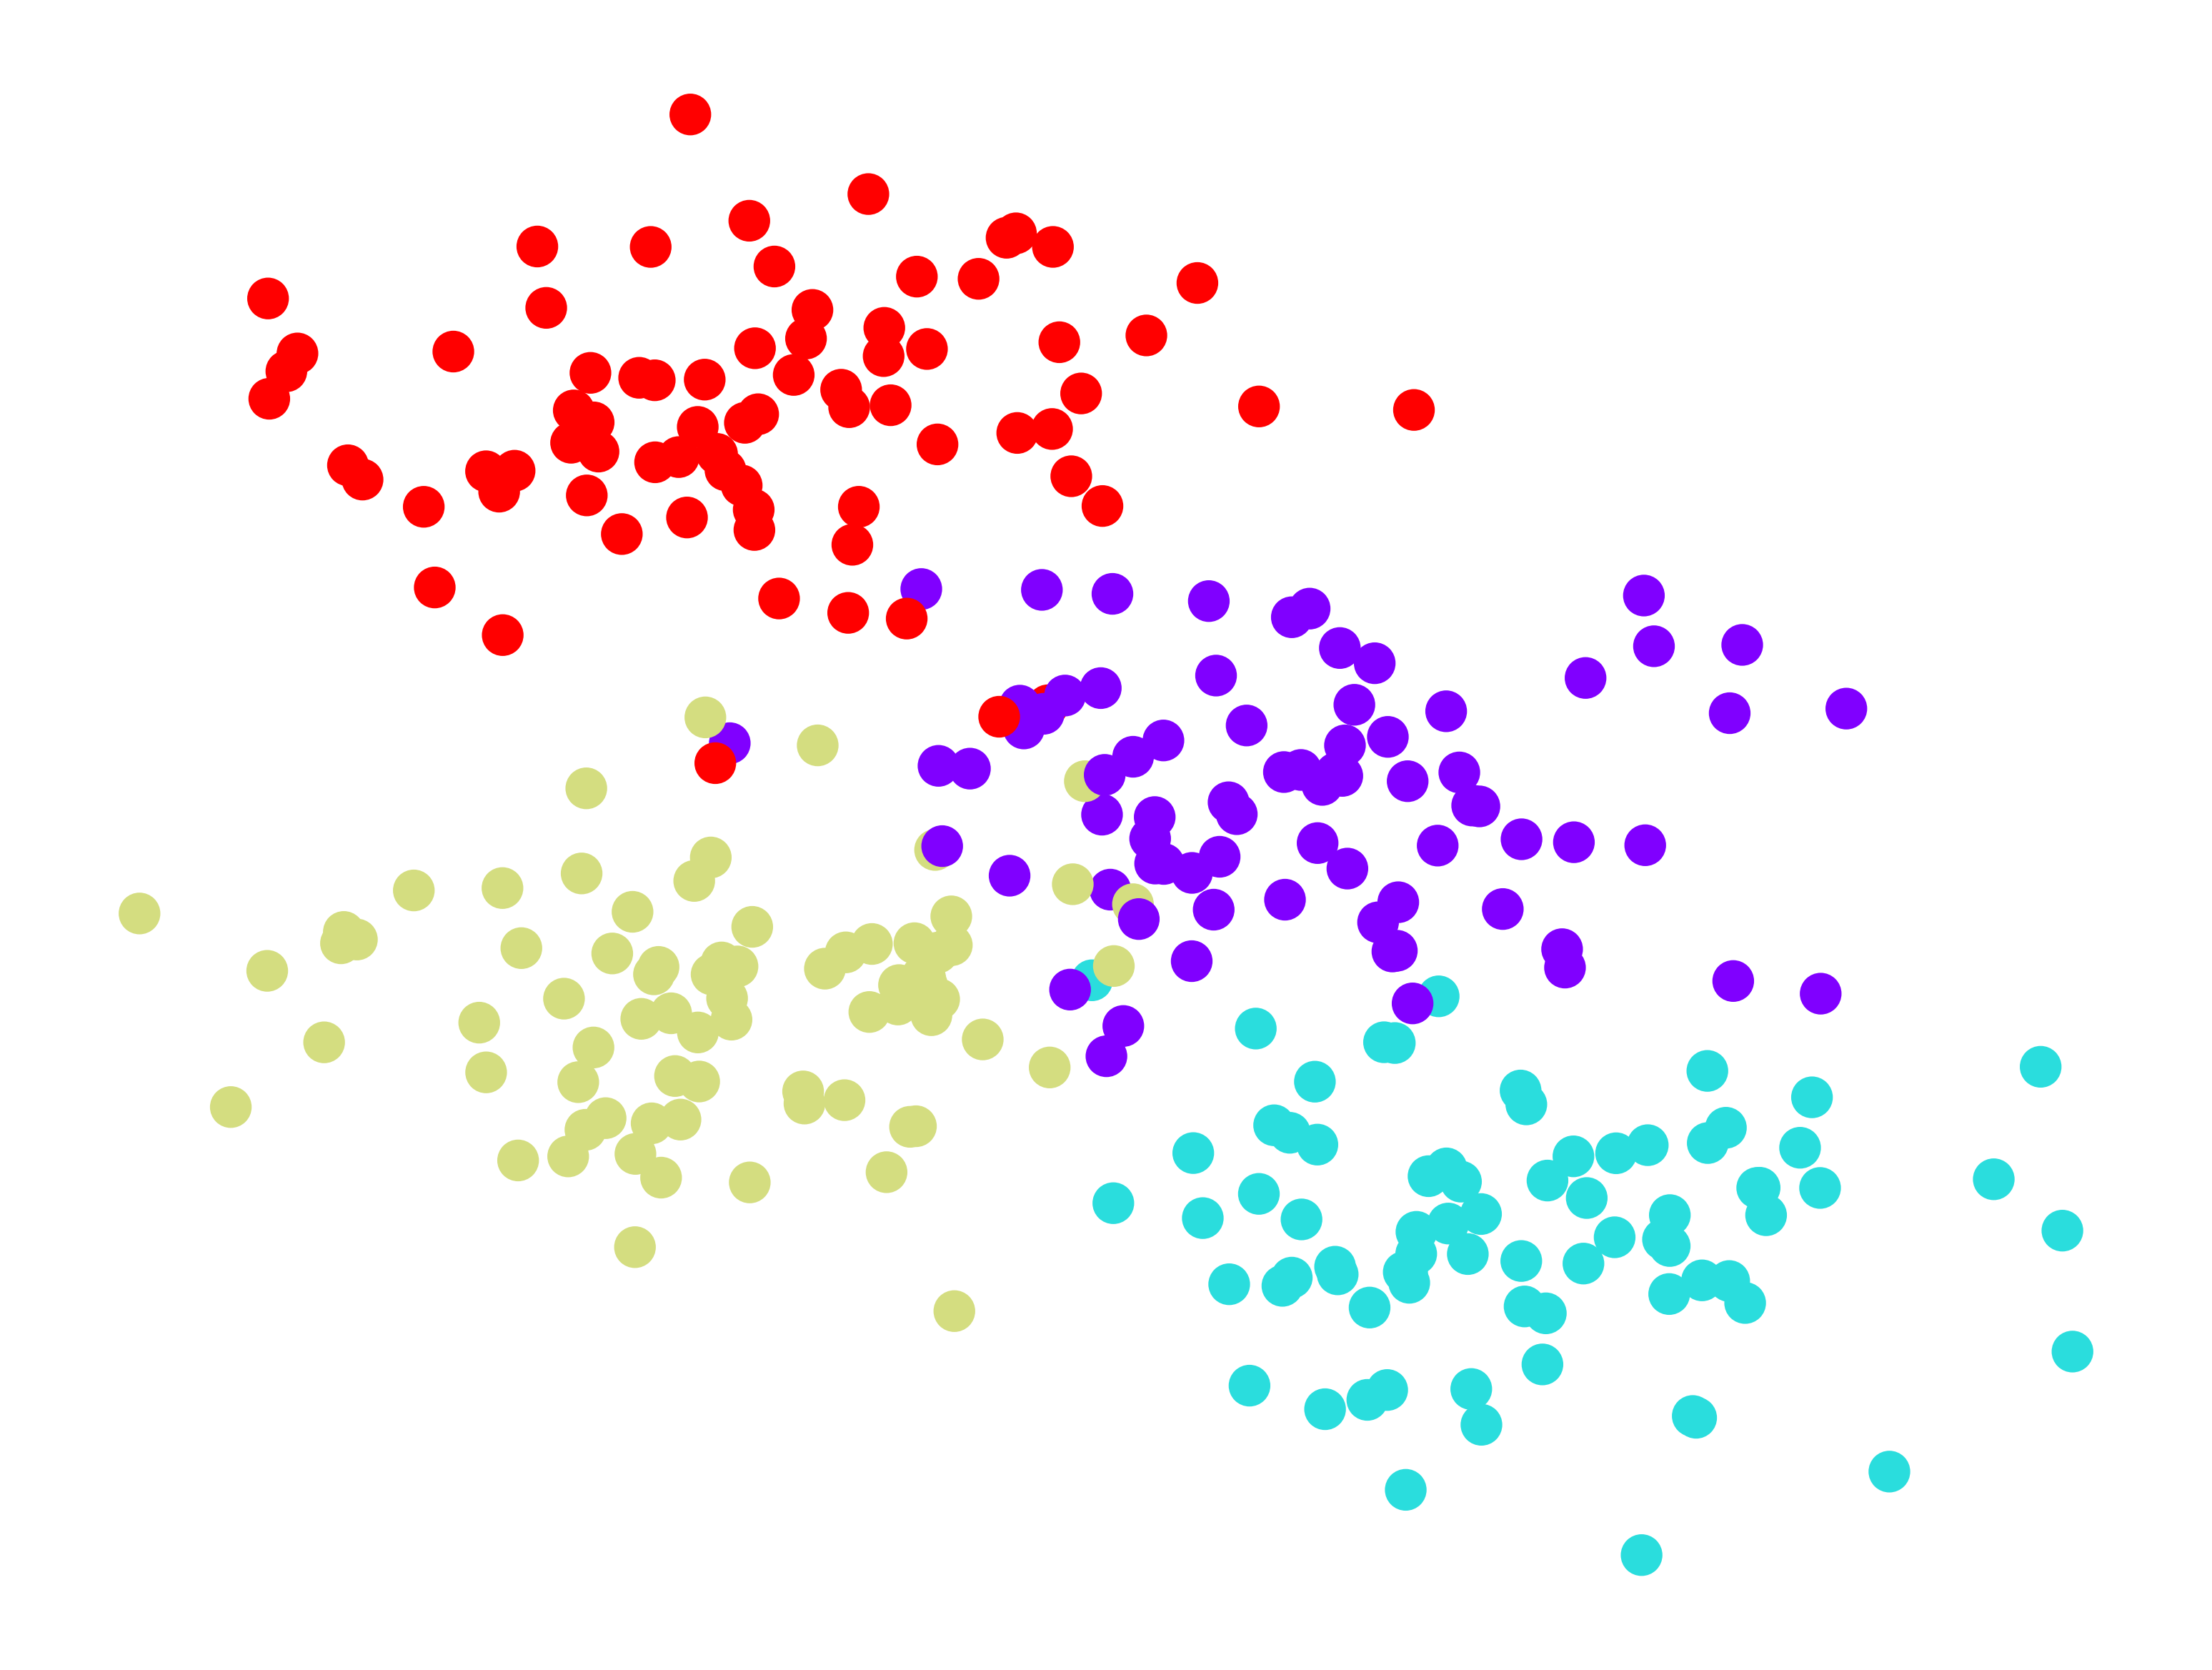

In [120]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=1.0)
# X has 2 features, and y consists of 4 classes

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='rainbow')
plt.axis('off')

In [121]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier().fit(X,y)

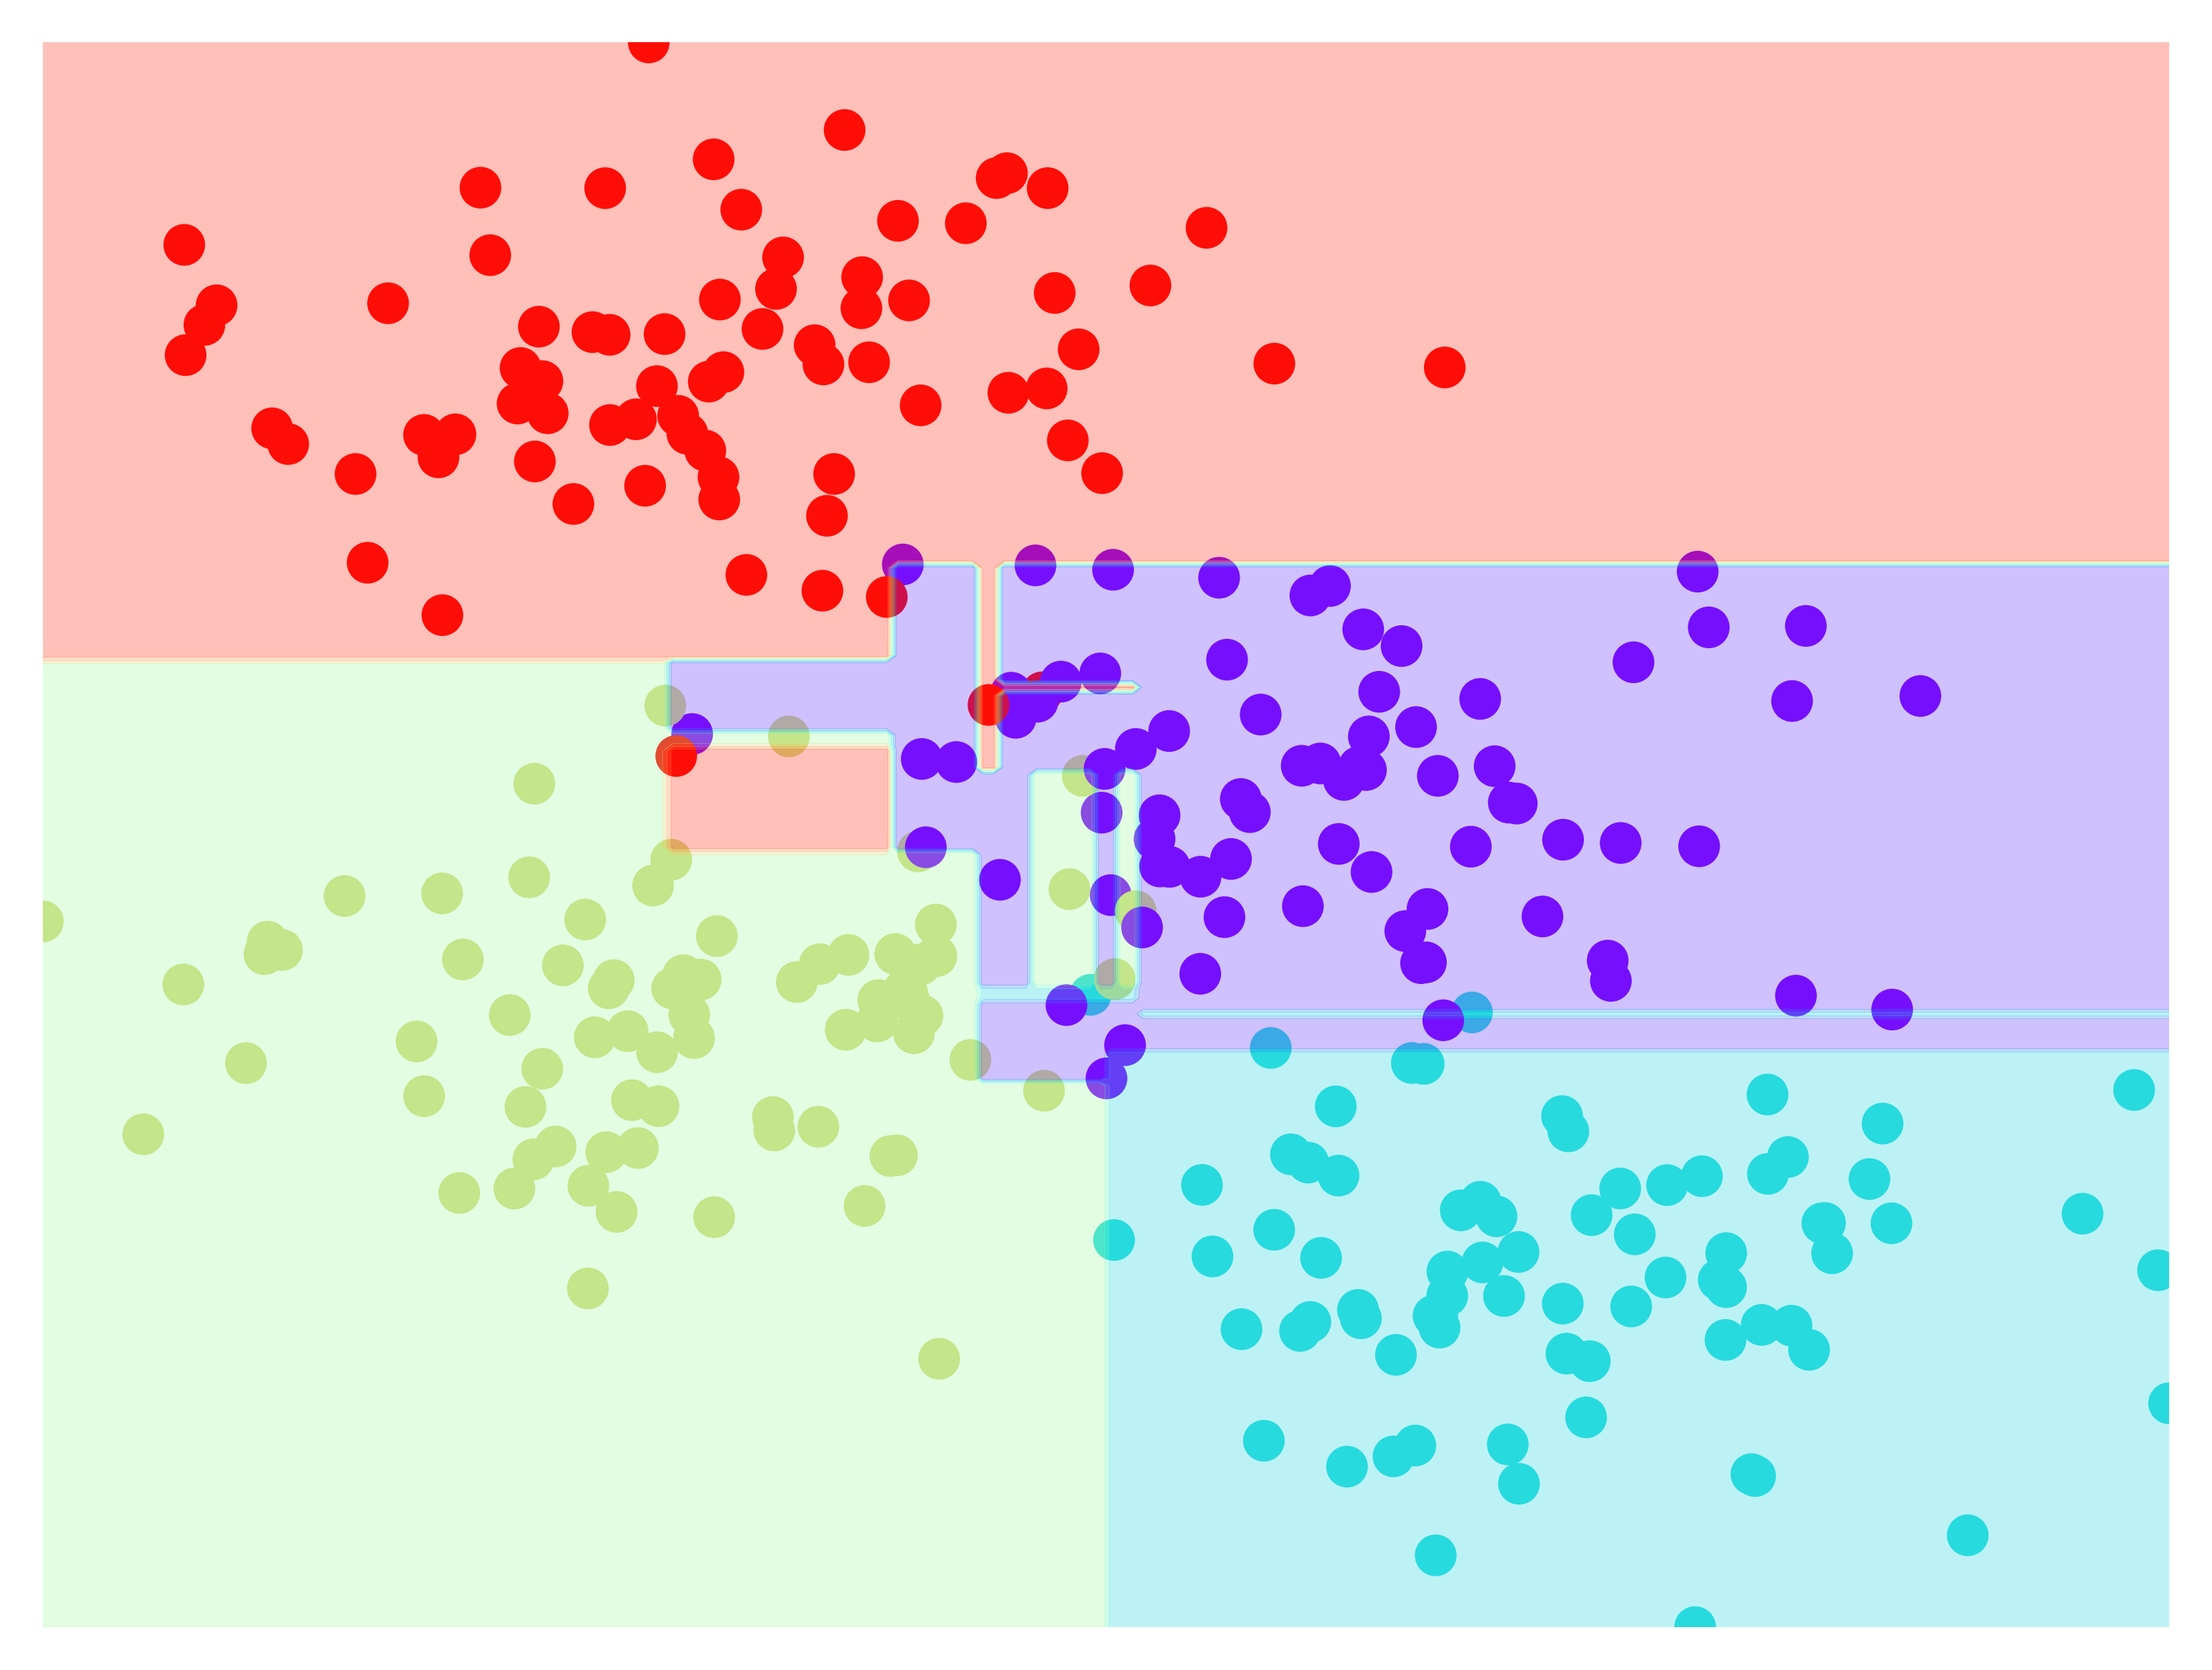

In [122]:
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 200),
    np.linspace(X[:,1].min(), X[:,1].max(), 200)
)
Z = tree.predict(np.column_stack([xx.ravel(), yy.ravel().T])).reshape(xx.shape)
n_classes = len(np.unique(y))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='rainbow')
plt.contourf(xx, yy, Z, cmap='rainbow', alpha=0.3)
plt.axis('off');

interactive(children=(IntSlider(value=5, description='depth', max=5, min=1), Output()), _dom_classes=('widget-…

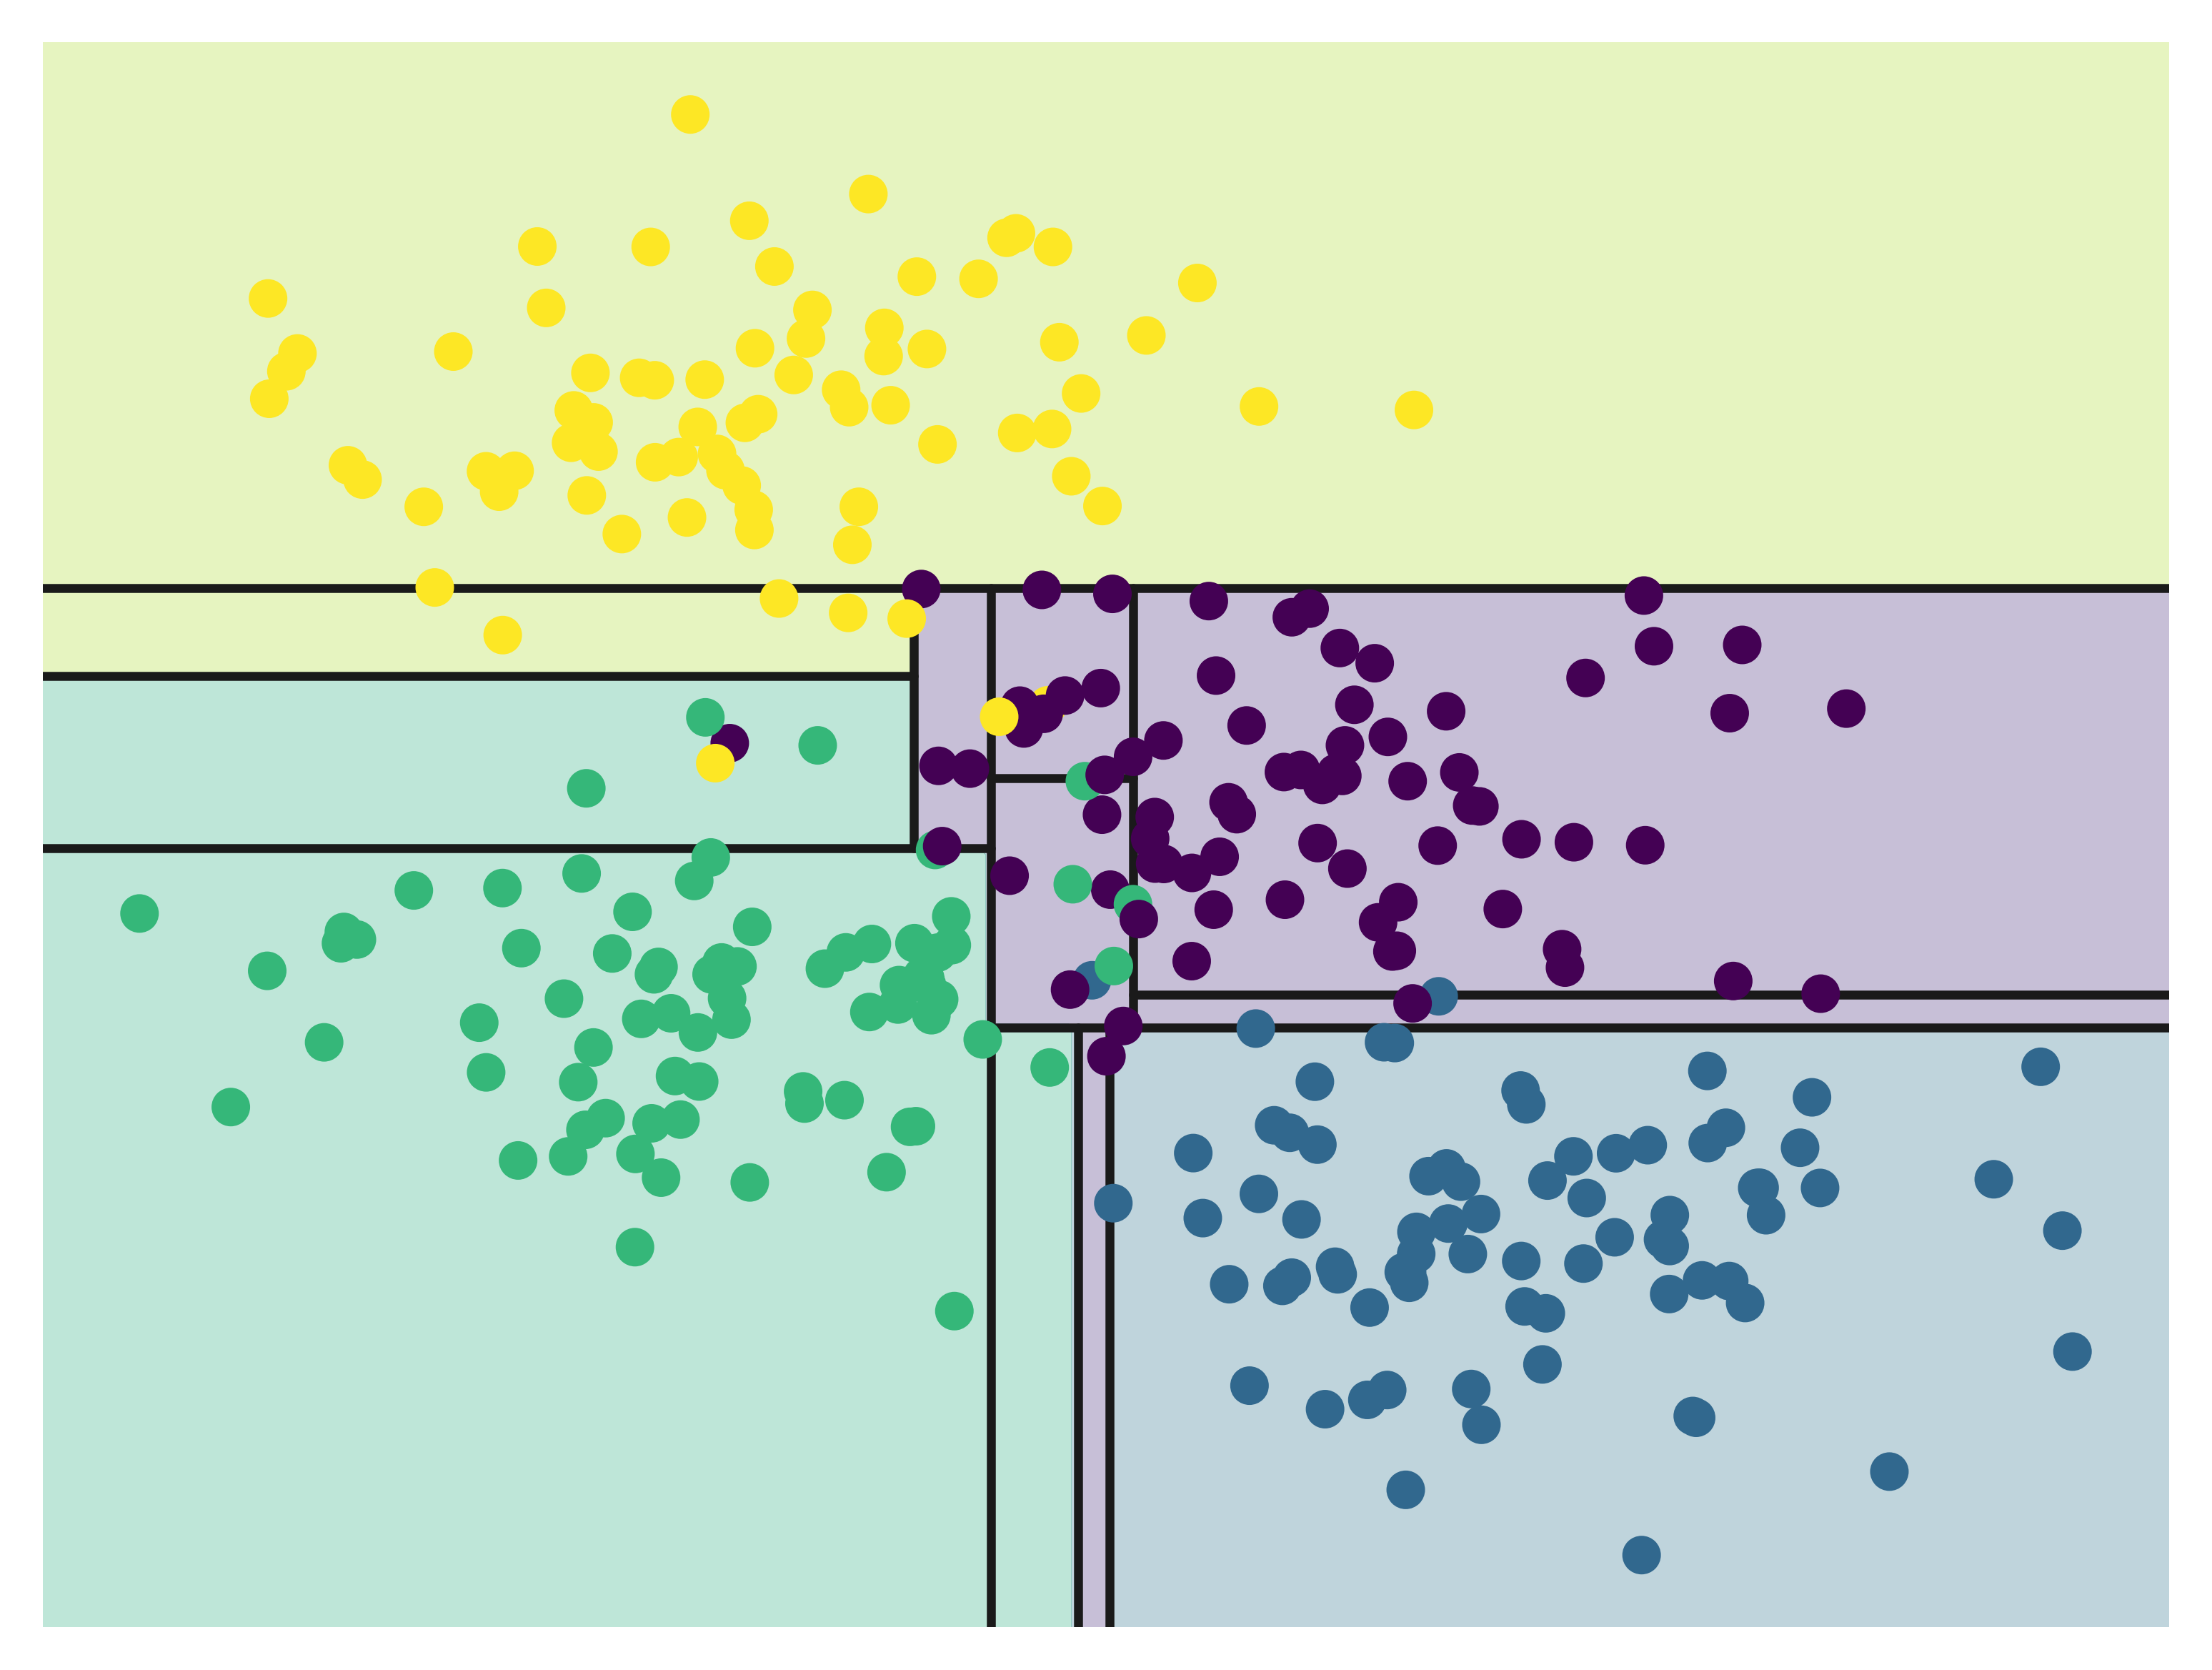

In [125]:
import sys
sys.path.append("/Users/jelo/IBM-Data-Science-Specialization/Course-9_Machine-Learning/scripts")

import helpers_05_08
helpers_05_08.plot_tree_interactive(X, y);

In [127]:
def visualize_classifier(model, X, y, cmap='rainbow'):
    xx, yy = np.meshgrid(
        np.linspace(X[:,0].min(), X[:,0].max(), 200),
        np.linspace(X[:,1].min(), X[:,1].max(), 200)
    )
    
    Z = model.predict(np.column_stack([xx.ravel(), yy.ravel().T])).reshape(xx.shape)
    
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap)
    plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)
    plt.axis('off');

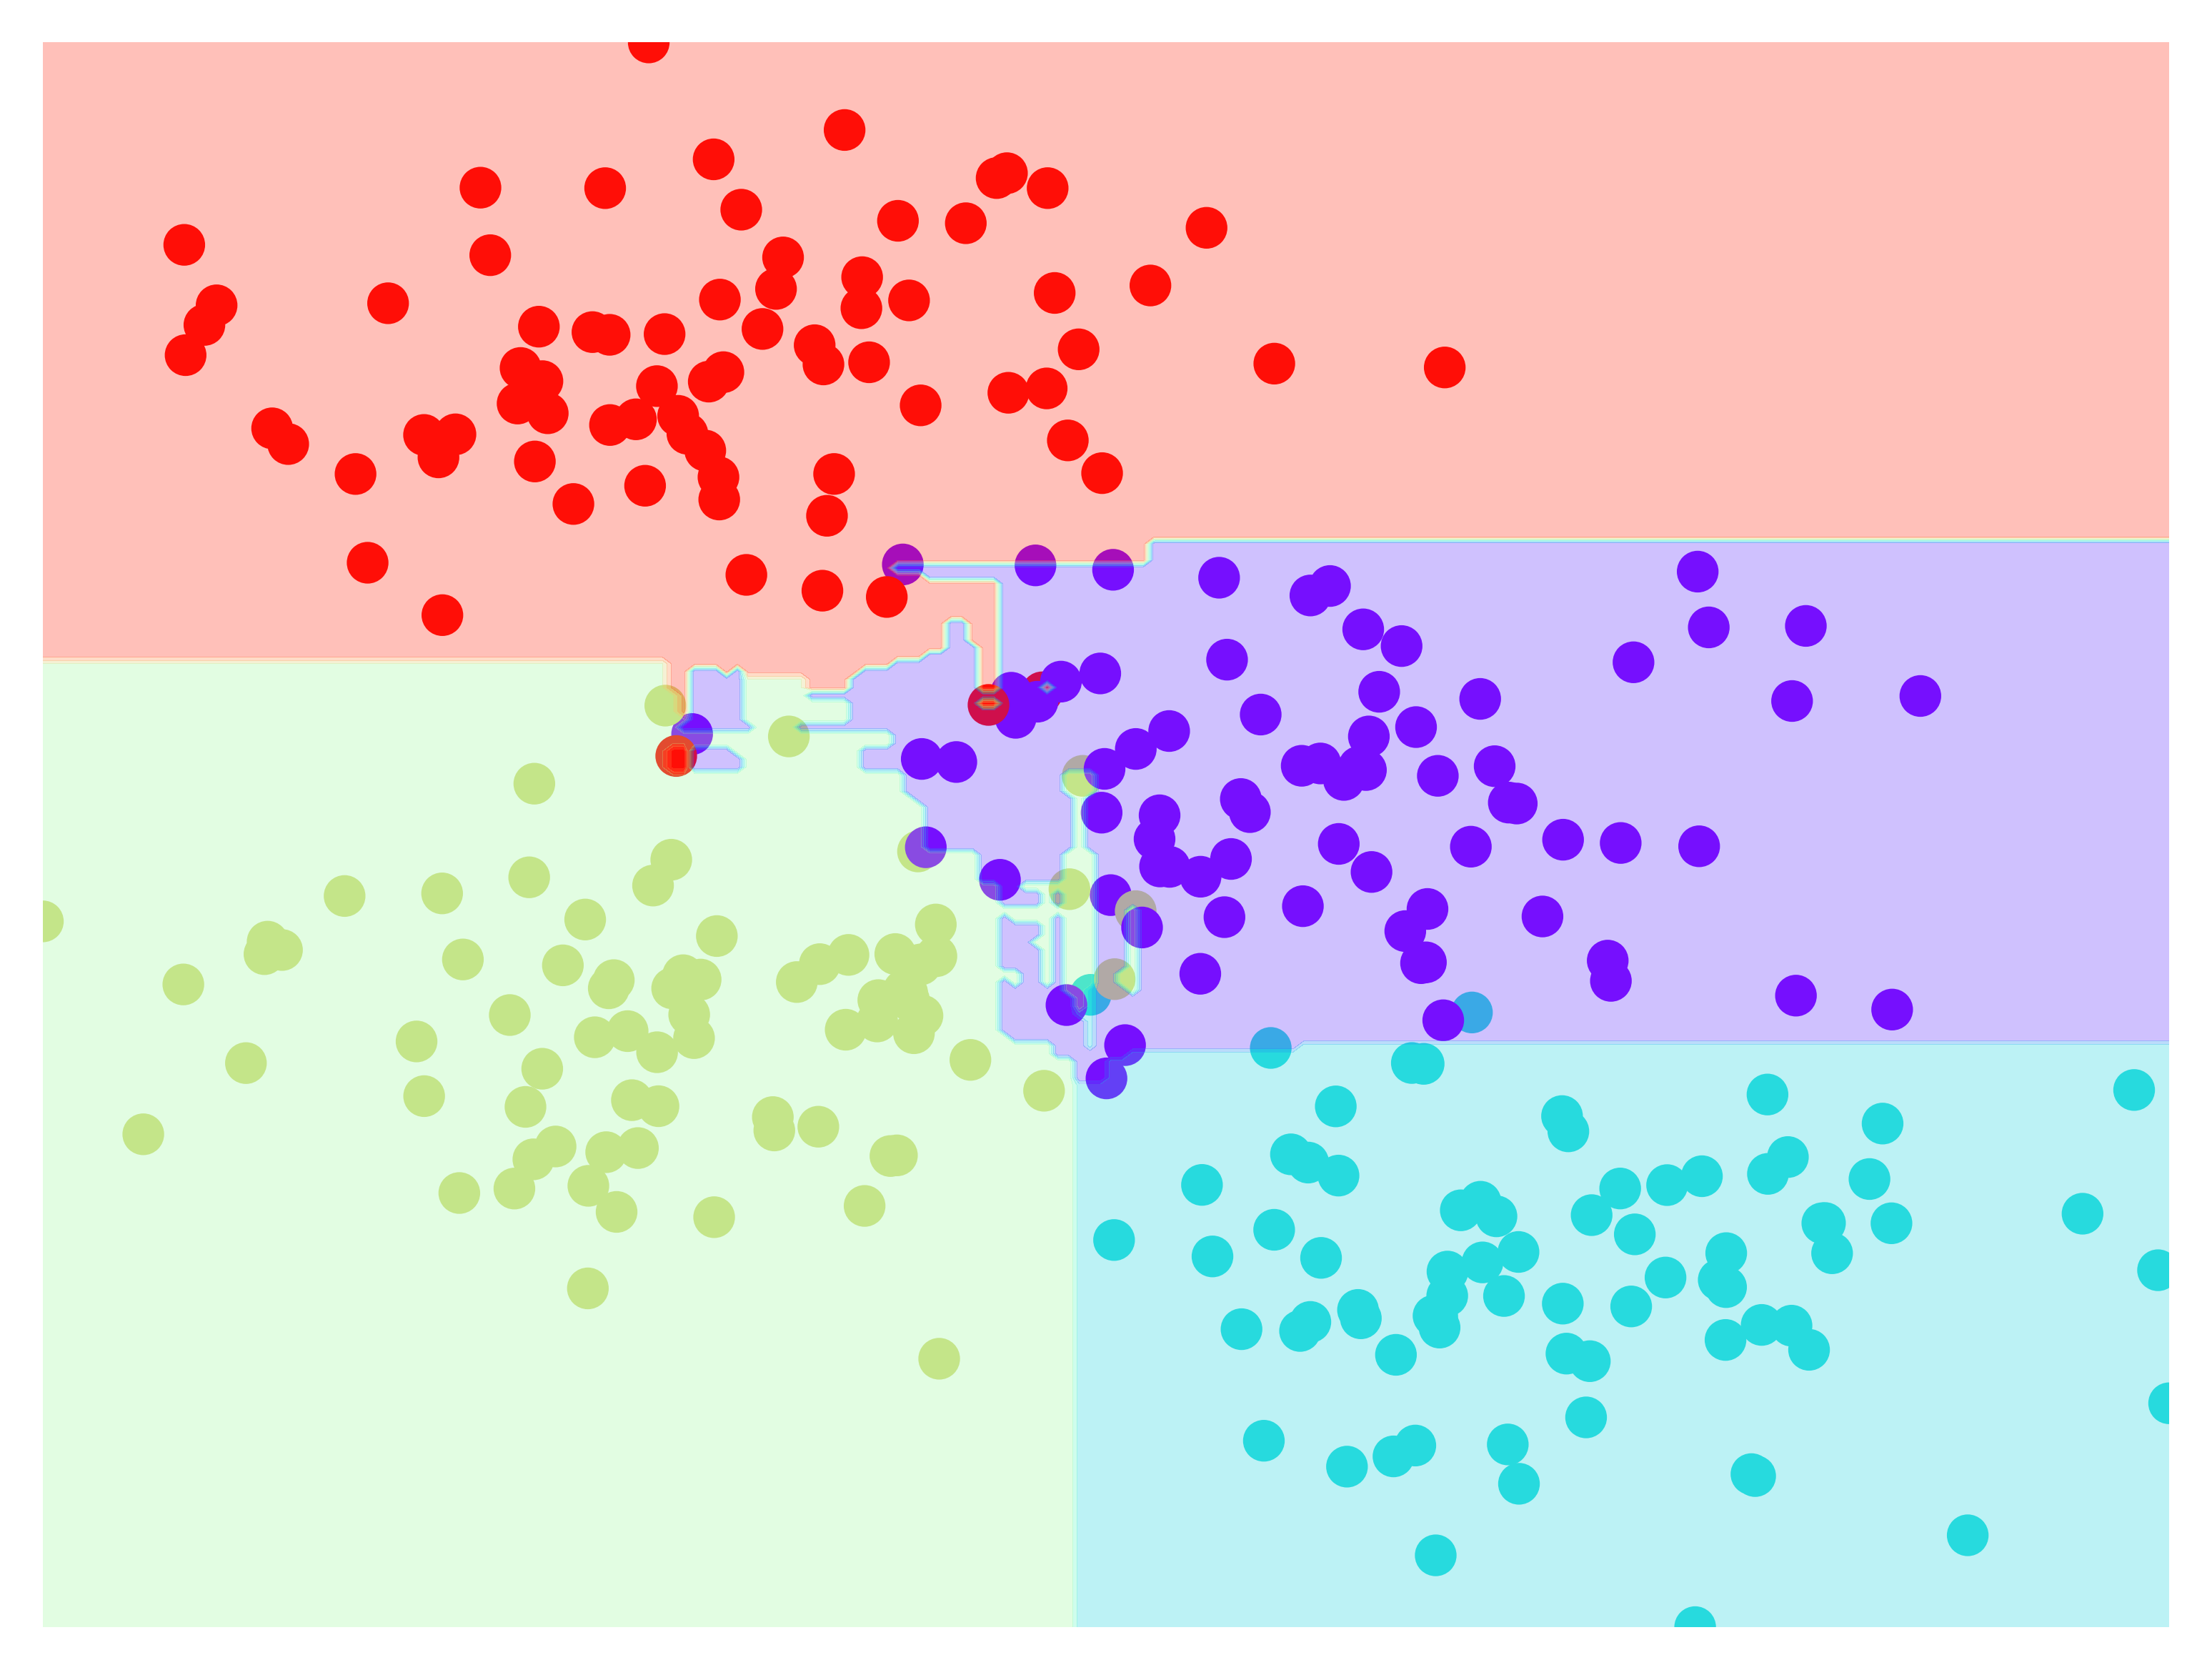

In [128]:
from sklearn.ensemble import BaggingClassifier

tree = DecisionTreeClassifier()
bag = BaggingClassifier(
    tree, n_estimators=100, max_samples=0.8, random_state=1
)
bag.fit(X,y)
visualize_classifier(bag, X, y)

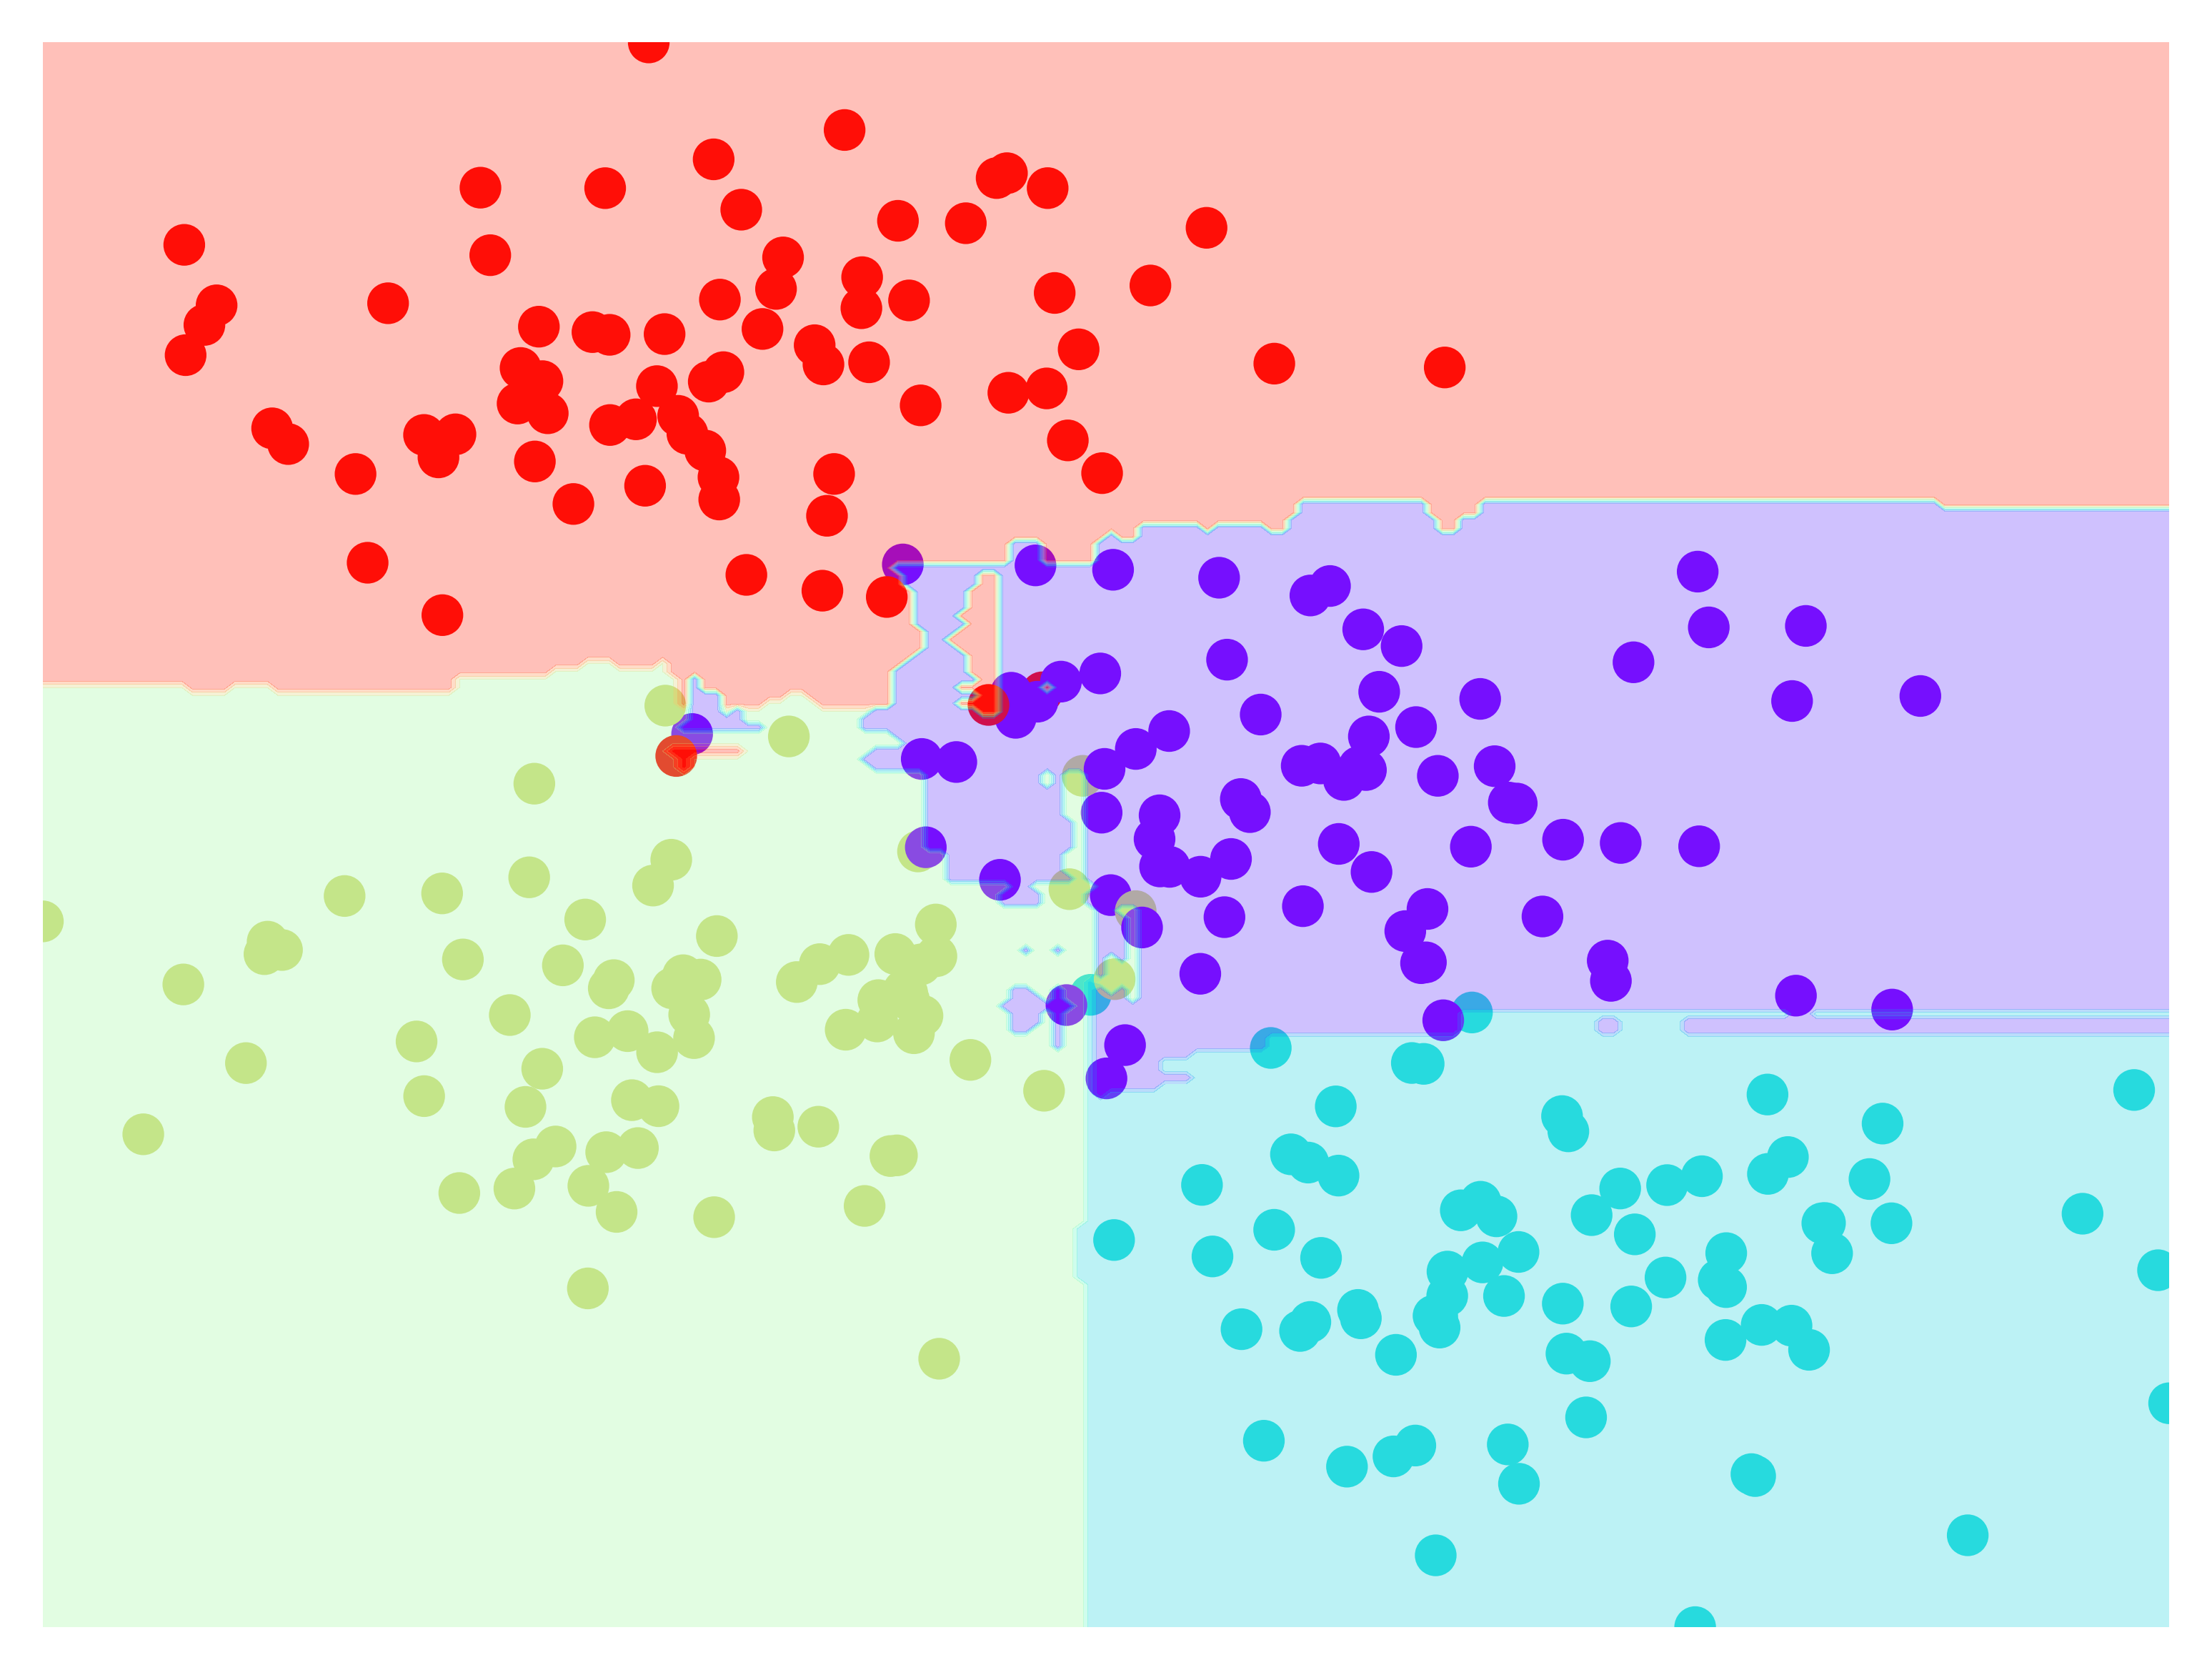

In [132]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X,y)
visualize_classifier(model, X, y)

### Review: Visualizing a Three-Dimensional Function -- Contour plots

array([[-0.83907153, -0.83470697, -0.8216586 , ...,  0.8956708 ,
         0.68617261,  0.41940746],
       [-0.83907153, -0.8275558 , -0.80744041, ...,  0.93467448,
         0.77467433,  0.55894214],
       [-0.83907153, -0.820263  , -0.79266951, ...,  0.98503397,
         0.88847607,  0.73757604],
       ...,
       [-0.83907153, -0.48696962, -0.02692065, ...,  0.98525345,
         0.79584263,  0.46799565],
       [-0.83907153, -0.47558005, -0.00130271, ...,  0.93488414,
         0.6993547 ,  0.37933079],
       [-0.83907153, -0.46410908,  0.02431613, ...,  0.89579384,
         0.65690314,  0.40107702]], shape=(40, 50))

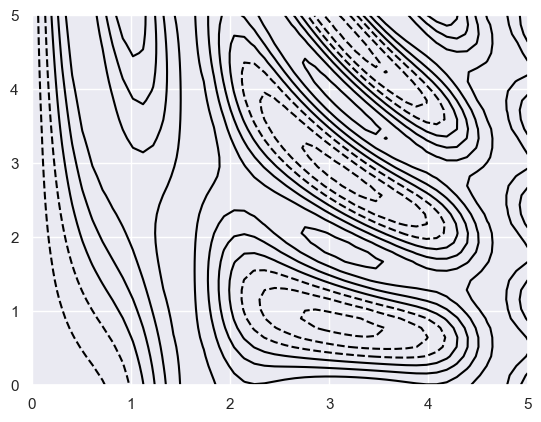

In [85]:
def f(x,y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x,y)
Z = f(X,Y)

plt.contour(X, Y, Z, colors='black');
Z

In [86]:
Z

array([[-0.83907153, -0.83470697, -0.8216586 , ...,  0.8956708 ,
         0.68617261,  0.41940746],
       [-0.83907153, -0.8275558 , -0.80744041, ...,  0.93467448,
         0.77467433,  0.55894214],
       [-0.83907153, -0.820263  , -0.79266951, ...,  0.98503397,
         0.88847607,  0.73757604],
       ...,
       [-0.83907153, -0.48696962, -0.02692065, ...,  0.98525345,
         0.79584263,  0.46799565],
       [-0.83907153, -0.47558005, -0.00130271, ...,  0.93488414,
         0.6993547 ,  0.37933079],
       [-0.83907153, -0.46410908,  0.02431613, ...,  0.89579384,
         0.65690314,  0.40107702]], shape=(40, 50))

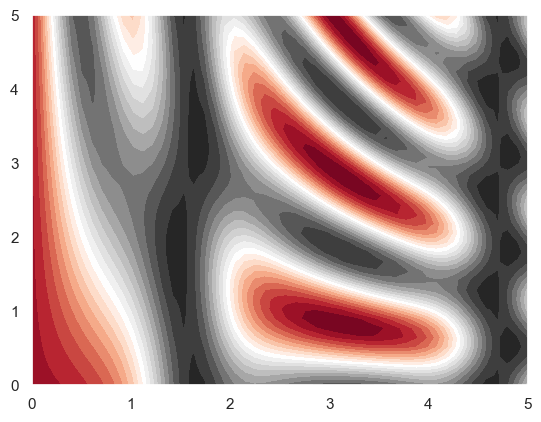

In [49]:
plt.contourf(X, Y, Z, 20, cmap='RdGy');